# Building an image recognition neural network

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

np.random.seed(0)
torch.manual_seed(1)

### Importing and reading the dataset

In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

x_train = train_dataset.data.numpy()         
y_train = train_dataset.targets.numpy()      
x_test  = test_dataset.data.numpy()           
y_test  = test_dataset.targets.numpy()       

print("Size of the training set", len(x_train))
print("Size of the testing set",  len(x_test))

Size of the training set 60000
Size of the testing set 10000


The label is 2


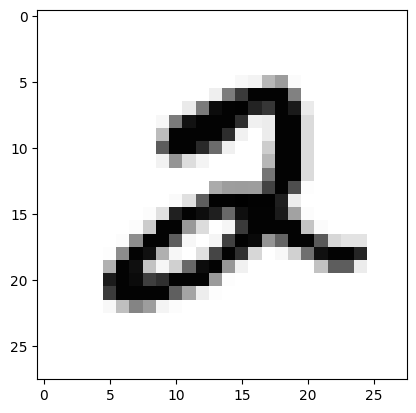

In [3]:
plt.imshow(x_train[5], cmap='Greys')
print("The label is", y_train[5])

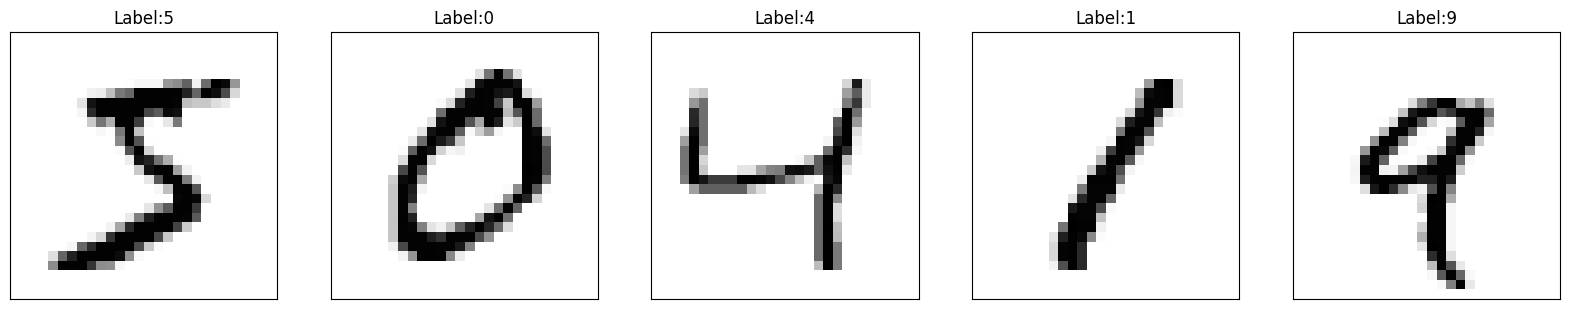

In [4]:
fig = plt.figure(figsize=(20, 20))
for i in range(5):
    ax = fig.add_subplot(1, 5, i + 1, xticks=[], yticks=[])
    ax.imshow(x_train[i], cmap='Greys')
    ax.set_title('Label:' + str(y_train[i]))

### Pre-processing the data

In [ ]:
x_train_reshaped = x_train.reshape(-1, 28 * 28).astype(np.float32) / 255.0
x_test_reshaped  = x_test.reshape(-1, 28 * 28).astype(np.float32) / 255.0

X_train_t = torch.tensor(x_train_reshaped)
y_train_t = torch.tensor(y_train, dtype=torch.long)   # CrossEntropyLoss expects class indices
X_test_t  = torch.tensor(x_test_reshaped)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=10, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=256, shuffle=False)

### Building and training the neural network

In [ ]:


model = nn.Sequential(
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 10)
)

criterion = nn.CrossEntropyLoss()          # categorical cross-entropy equivalent
optimizer = optim.Adam(model.parameters())


Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=64, out_features=10, bias=True)
)


In [13]:
epochs = 10

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    correct = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        correct += (outputs.argmax(dim=1) == y_batch).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc  = correct / len(train_loader.dataset)
    print(f"Epoch {epoch}/{epochs}  loss: {epoch_loss:.4f}  accuracy: {epoch_acc:.4f}")

Epoch 1/10  loss: 0.2987  accuracy: 0.9098
Epoch 2/10  loss: 0.1564  accuracy: 0.9533
Epoch 3/10  loss: 0.1249  accuracy: 0.9624
Epoch 4/10  loss: 0.1091  accuracy: 0.9670
Epoch 5/10  loss: 0.0994  accuracy: 0.9699
Epoch 6/10  loss: 0.0912  accuracy: 0.9718
Epoch 7/10  loss: 0.0850  accuracy: 0.9745
Epoch 8/10  loss: 0.0780  accuracy: 0.9762
Epoch 9/10  loss: 0.0755  accuracy: 0.9768
Epoch 10/10  loss: 0.0725  accuracy: 0.9776


### Making predictions

In [ ]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t)            

predictions = logits.argmax(dim=1).numpy()

The label is 4
The prediction is 4


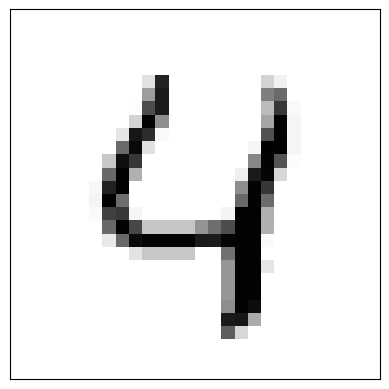

In [16]:
plt.imshow(x_test[4], cmap='Greys')
plt.xticks([])
plt.yticks([])
print("The label is",      y_test[4])
print("The prediction is", predictions[4])

Sometimes the model makes mistakes too.

The label is 5
The prediction is 5


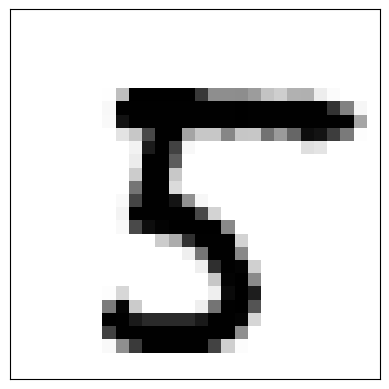

In [27]:
import random
idx = random.randint(0,len(x_test))

plt.imshow(x_test[idx], cmap='Greys')
plt.xticks([])
plt.yticks([])


print("The label is",      y_test[idx])
print("The prediction is", predictions[idx])

### Finding the accuracy of the model on the test set

In [14]:
num_correct = 0
for i in range(len(predictions)):
    if predictions[i] == y_test[i]:
        num_correct += 1

print("The model is correct", num_correct, "times out of", len(y_test))
print("The accuracy is", num_correct / len(y_test))

NameError: name 'predictions' is not defined

In [9]:
torch.save(model.state_dict(), "mnist_model.pth")